# Study 325 -- Crypto-Fear-Greed 😨
### For the curious: does the crypto Fear & Greed gauge time Bitcoin?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Gauge: Price--derived_proxy](https://img.shields.io/badge/Gauge-Price--derived_proxy-8b949e?style=flat-square)

The crypto **Fear & Greed Index** is a 0--100 mood ring for Bitcoin: 0 is
"Extreme Fear", 100 is "Extreme Greed". The folk rule -- a retail-friendly take on
Warren Buffett's *"be greedy when others are fearful"* -- says **buy when the
gauge is in Extreme Fear and sell when it is in Extreme Greed**. We put that
intuition on the clock.

> 📓 **This is the plain-language layer.** The statistics, the bootstrap and the
> capacity maths live in the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research; every chart is
> generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_fear_greed import data, strategy as st
import pandas as pd

# Real tape: cache-first, drop the partial current month so the as-of is clean.
AS_OF = pd.Timestamp("2026-05-31")
_close = data.load_real(fetch=False)
if _close is not None:
    _close = _close[_close.index <= AS_OF]
    panel = data.panel_from_close(_close)
    fr = st.forward_returns(panel)
    spread = st.spread_returns(fr)
    rm = st.regime_means(fr)
    HAVE_REAL = True
    print(f"REAL BTC tape: {_close.index[0].date()} -> {_close.index[-1].date()} ({len(_close)} days)")
else:
    panel = fr = spread = rm = None
    HAVE_REAL = False
    print("No BTC cache -- frozen headline numbers (R dict, mirror of docs/results.md) will be used.")


REAL BTC tape: 2014-09-17 -> 2026-05-31 (4275 days)


In [2]:

# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-05-31).
R = {'n_days': 4275, 'gauge_rows': 4125, 'stamp': '2014-09-17 -> 2026-05-31', 'fingerprint': '26bfad39f376', 'uncond_ann': 71.91, 'ef_ann': 125.49, 'ef_t': 2.12, 'ef_n': 603, 'fear_ann': 35.18, 'fear_t': 0.77, 'fear_n': 850, 'neu_ann': -3.01, 'neu_t': -0.07, 'neu_n': 619, 'greed_ann': 53.64, 'greed_t': 1.66, 'greed_n': 1363, 'eg_ann': 173.76, 'eg_t': 3.58, 'eg_n': 689, 'spread_bps': -2.93, 'spread_ann': -10.68, 'spread_t': -0.86, 'spread_hit': 0.153, 'spread_sr': -0.26, 'spread_ci_lo': -0.869, 'spread_ci_hi': 0.357, 'spread_frac_neg': 79, 'fear_excess_ann': 53.58, 'fear_excess_t': 0.9, 'slope_bps': 9.44, 'slope_t': 0.73, 'sub_a_ann': -11.74, 'sub_a_t': -0.46, 'sub_a_n': 1461, 'sub_b_ann': 10.94, 'sub_b_t': 0.51, 'sub_b_n': 1096, 'sub_c_ann': -23.94, 'sub_c_t': -1.5, 'sub_c_n': 1246, 'null_mean_bps': -0.31, 'null_std_bps': 2.93, 'real_pctile': 17.9, 'pct_long': 14.6, 'pct_flat': 68.7, 'pct_short': 16.7, 'n_trades': 362, 'trades_per_year': 32.0, 'net_ann': -15.56, 'net_t': -1.25, 'ctrl_0_bps': -3.39, 'ctrl_0_t': -0.83, 'ctrl_20_bps': 4.14, 'ctrl_20_t': 1.11, 'ctrl_35_bps': 10.99, 'ctrl_35_t': 2.88, 'ctrl_50_bps': 22.31, 'ctrl_50_t': 5.37}


## The answer first 🎯

| Question | Answer |
|---|---|
| Does "buy crypto fear" time BTC? | **No.** The contrarian spread is *negative* (-10.7%/yr, *t* = -0.86) -- the wrong sign. |
| Which mood paid the most next day? | **Extreme Greed** (+173.8%/yr, *t* = +3.58) -- the opposite of the claim. |
| Could you trade it? | No -- it loses before costs, and crypto short funding makes it worse. |

Bitcoin *trends*: it keeps running when the gauge says greed. The contrarian rule
is fighting the single most powerful thing about crypto -- its momentum.


## 1 · The claim

> *Be greedy when others are fearful.* When the [crypto Fear & Greed Index](https://alternative.me/crypto/fear-and-greed-index/)
> drops into Extreme Fear, that's the buying opportunity; when it spikes into
> Extreme Greed, take profits.

It *feels* obviously right -- surely the best time to buy BTC was the despair of
the 2018 / 2022 crypto winters, and the worst was the euphoric tops.


## 2 · So what?

If a free, public mood gauge timed a 70%/yr asset, that is a fortune in a browser
tab. It would also say something deep: that crowd emotion is a *leading*, tradable
signal in the most retail-driven market there is.


## 3 · How would we even know?

We rebuild a transparent gauge from BTC's own price (its **volatility**,
**drawdown** and **momentum** -- the live index's heaviest weights), sort every
day into the five published bands, and measure the **average return over the
following day**. If the contrarian claim were true, the Extreme-Fear bar would
tower over the Extreme-Greed bar.


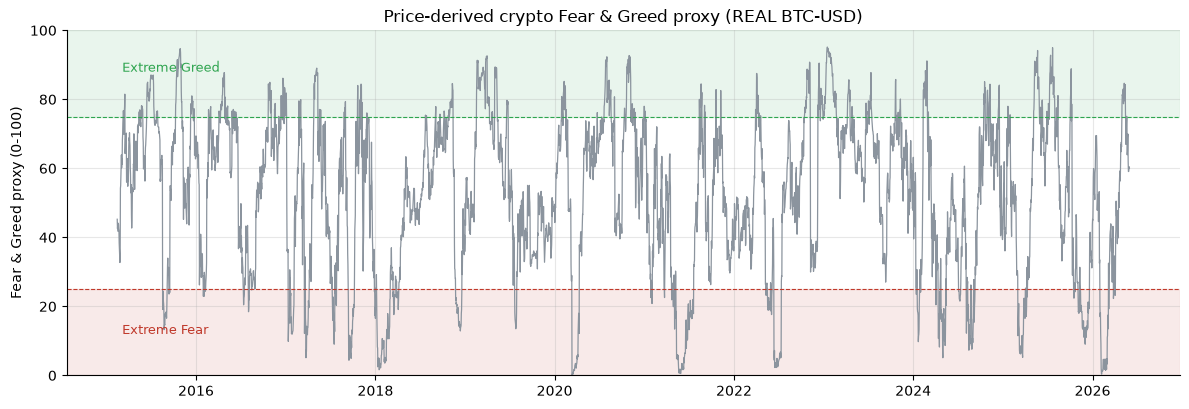

Tape shown: REAL BTC-USD. The gauge is built from BTC vol + drawdown + momentum -- no social/search data.


In [3]:
# The price-derived gauge over the BTC tape (SYNTHETIC fallback bannered if no cache).
if HAVE_REAL:
    fng_s = panel["fng"]; tape = "REAL BTC-USD"
else:
    _d, _ = data.synthetic_btc(reversion=0.0, seed=325)
    _p = data.panel_from_close(_d["close"]); fng_s = _p["fng"]; tape = "SYNTHETIC (offline fallback)"
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(fng_s.index, fng_s.values, color=GREY, lw=0.9)
ax.axhspan(0, 25, color=RED, alpha=0.10); ax.axhspan(75, 100, color=GREEN, alpha=0.10)
ax.axhline(25, color=RED, lw=0.8, ls="--"); ax.axhline(75, color=GREEN, lw=0.8, ls="--")
ax.text(fng_s.index[20], 12, "Extreme Fear", color=RED, fontsize=9)
ax.text(fng_s.index[20], 88, "Extreme Greed", color=GREEN, fontsize=9)
ax.set_ylim(0, 100); ax.set_ylabel("Fear & Greed proxy (0-100)")
ax.set_title(f"Price-derived crypto Fear & Greed proxy ({tape})")
plt.tight_layout(); plt.savefig("../docs/gauge_series.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"Tape shown: {tape}. The gauge is built from BTC vol + drawdown + momentum -- no social/search data.")


## 4 · The teardown -- what happens the day *after* each mood?

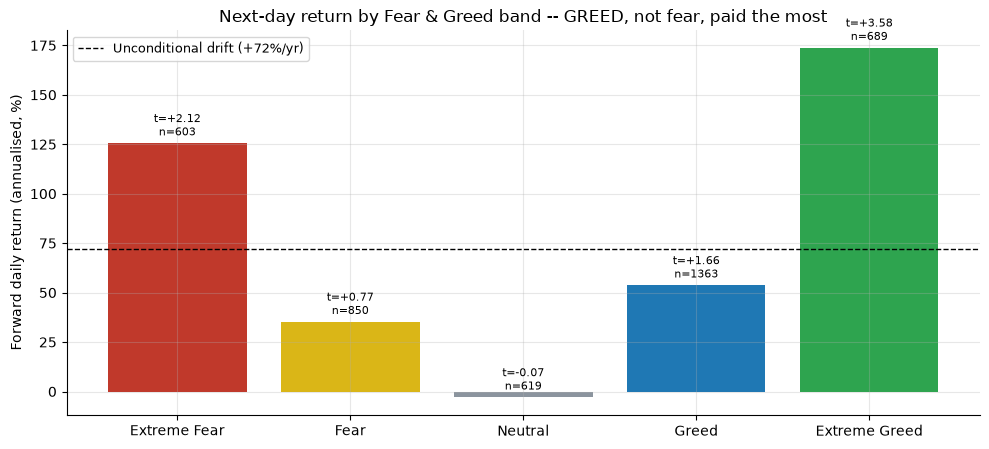

The tallest bar is EXTREME GREED, not Extreme Fear -- the opposite of the contrarian claim.


In [4]:
bands = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
if HAVE_REAL:
    anns = [rm.loc[b, "mean_ann"]*100 for b in bands]
    ts   = [rm.loc[b, "tstat"] for b in bands]
    ns   = [int(rm.loc[b, "n"]) for b in bands]
    uncond = fr["fwd_ret"].mean()*365*100
else:
    anns = [R["ef_ann"], R["fear_ann"], R["neu_ann"], R["greed_ann"], R["eg_ann"]]
    ts   = [R["ef_t"], R["fear_t"], R["neu_t"], R["greed_t"], R["eg_t"]]
    ns   = [R["ef_n"], R["fear_n"], R["neu_n"], R["greed_n"], R["eg_n"]]
    uncond = R["uncond_ann"]
colors = [RED, AMBER, GREY, "#1f78b4", GREEN]
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(bands, anns, color=colors)
ax.axhline(uncond, color="black", ls="--", lw=1.0, label=f"Unconditional drift ({uncond:+.0f}%/yr)")
for i,(a,t,n) in enumerate(zip(anns, ts, ns)):
    ax.text(i, a + 4, f"t={t:+.2f}\nn={n}", ha="center", fontsize=8)
ax.set_ylabel("Forward daily return (annualised, %)")
ax.set_title("Next-day return by Fear & Greed band -- GREED, not fear, paid the most")
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig("../docs/by_band.png", dpi=120, bbox_inches="tight"); plt.show()
print("The tallest bar is EXTREME GREED, not Extreme Fear -- the opposite of the contrarian claim.")


## 5 · The verdict

Buying fear and shorting greed -- the literal contrarian trade -- *lost* money:
**-10.7%/yr, *t* = -0.86**, the wrong sign. Shuffling the gauge at random does
*better* on average (the real spread sits at the 17.9th percentile of that null).
The gauge is a fine thermometer for crypto mood and a useless -- in fact
backwards -- clock. **Signal: None.**


In [5]:
print("=== Does the crypto Fear & Greed gauge time BTC? ===\n")
print(f"Contrarian long-fear/short-greed spread: {R['spread_ann']:+.2f}%/yr  HAC t = {R['spread_t']:+.2f}  (WRONG SIGN)")
print(f"  Bootstrap Sharpe 95% CI: [{R['spread_ci_lo']:+.2f}, {R['spread_ci_hi']:+.2f}]  ({R['spread_frac_neg']}% of resamples negative)")
print(f"  Real spread vs shuffled-gauge null: {R['real_pctile']:.1f}th percentile (worse than most random relabellings)")
print("\nVerdict: Signal NONE / Tradability MIRAGE -- a great thermometer, a backwards clock.")


=== Does the crypto Fear & Greed gauge time BTC? ===

Contrarian long-fear/short-greed spread: -10.68%/yr  HAC t = -0.86  (WRONG SIGN)
  Bootstrap Sharpe 95% CI: [-0.87, +0.36]  (79% of resamples negative)
  Real spread vs shuffled-gauge null: 17.9th percentile (worse than most random relabellings)

Verdict: Signal NONE / Tradability MIRAGE -- a great thermometer, a backwards clock.


## 6 · Could you actually trade it?

No. There is no gross edge to erode -- the spread loses *before* a cent of costs.
And crypto shorts are dear: perp funding plus spot borrow run into the high
hundreds of bps a year. Charging a realistic 1000 bps/yr on the short leg drives
the spread to **-15.6%/yr**. You would be paying to lose.


## 7 · Going further 🚪

- Swap the price-derived proxy for the **real alternative.me index** once an
  archive is reachable -- does the social/search component add anything the
  vol/momentum legs miss?
- Test the gauge as a **momentum confirm** (buy greed) rather than a contrarian
  fade -- the band table hints that is the side with the *t*-stat.
- Re-run on **ETH and an alt basket**: is the wrong-sign result a BTC-trend
  artefact or universal?

*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md).*
